In [126]:
import pandas as pd


In [127]:
df=pd.read_csv("train.csv")

In [ ]:
df.head(
    
)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [129]:
mean=df['Item_Weight'].mean()
df['Item_Weight'].fillna(mean,inplace=True)
#df=df.dropna()

C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_24336\1989943043.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(mean,inplace=True)


In [130]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [131]:
df.drop(["Item_Identifier","Outlet_Identifier"],axis=1,inplace=True)

In [132]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Item_Fat_Content"]=le.fit_transform(df["Item_Fat_Content"])
df["Item_Type"]=le.fit_transform(df["Item_Type"])
df["Outlet_Size"]=le.fit_transform(df["Outlet_Size"])
df["Outlet_Location_Type"]=le.fit_transform(df["Outlet_Location_Type"])
df["Outlet_Type"]=le.fit_transform(df["Outlet_Type"])


In [133]:
df.shape

(8523, 10)

<Axes: >

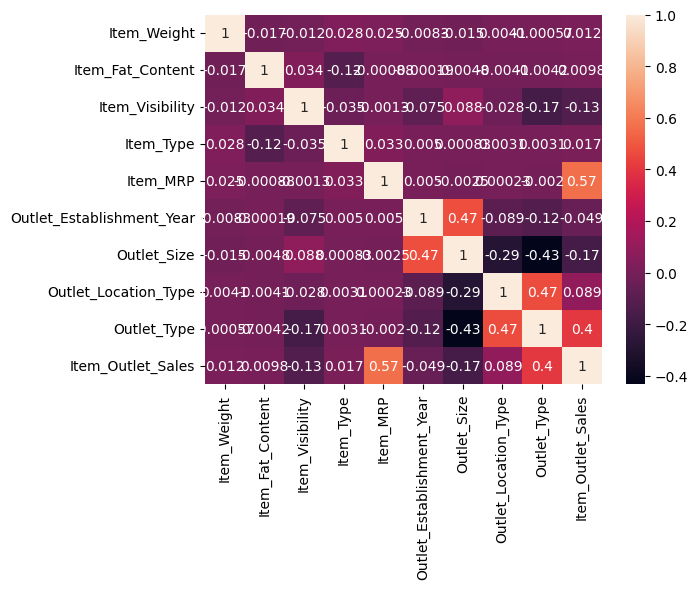

In [134]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [135]:
df.isnull().sum()

Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [136]:
X=df.copy()
X.drop(["Item_Outlet_Sales"],inplace=True,axis=1)

In [137]:
y=df["Item_Outlet_Sales"]

In [138]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

In [139]:
from sklearn import neighbors
model=neighbors.KNeighborsRegressor(n_neighbors=8)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


In [140]:
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

0.4400725776130028


In [141]:
from sklearn.metrics import root_mean_squared_error
error=root_mean_squared_error(y_test,y_pred)

In [142]:
error

1233.6393206791506

In [143]:
rmse_val=[]
k_list=[]
for k in range(50):
    k=k+1
    model=neighbors.KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    error=root_mean_squared_error(y_test,y_pred)
    rmse_val.append(error)
    k_list.append(k)
    print("RMSE value for k=",k,"is",error)

RMSE value for k= 1 is 1577.31330441717
RMSE value for k= 2 is 1393.1064032757738
RMSE value for k= 3 is 1322.8514946826147
RMSE value for k= 4 is 1285.066441373215
RMSE value for k= 5 is 1266.5806845061106
RMSE value for k= 6 is 1245.2740148987557
RMSE value for k= 7 is 1240.4727429153793
RMSE value for k= 8 is 1233.6393206791506
RMSE value for k= 9 is 1241.2661126871396
RMSE value for k= 10 is 1243.4854408354852
RMSE value for k= 11 is 1241.166982686332
RMSE value for k= 12 is 1243.3944336044353
RMSE value for k= 13 is 1241.705099679033
RMSE value for k= 14 is 1241.5066713067827
RMSE value for k= 15 is 1241.4005567046827
RMSE value for k= 16 is 1243.2893764867397
RMSE value for k= 17 is 1248.7622321504352
RMSE value for k= 18 is 1247.8461218284203
RMSE value for k= 19 is 1250.6961466704033
RMSE value for k= 20 is 1253.7532421296496
RMSE value for k= 21 is 1253.945755046427
RMSE value for k= 22 is 1258.3924494303121
RMSE value for k= 23 is 1262.0787175618086
RMSE value for k= 24 is 12

In [144]:
best_rmse=min(rmse_val)
best_k=k_list[rmse_val.index(best_rmse)]
print(best_k)
print(best_rmse)


8
1233.6393206791506


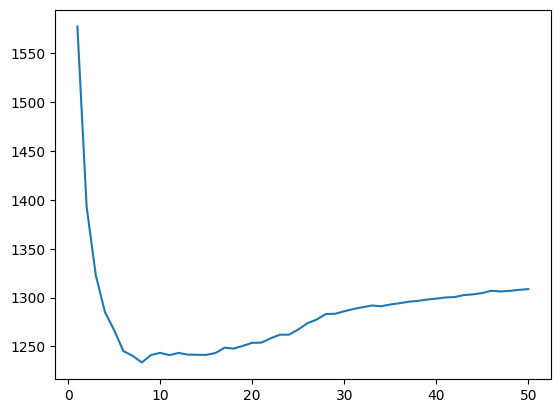

In [145]:
import matplotlib.pyplot as plt
plt.plot(k_list,rmse_val)